# Excercise 3 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lasio
import rockphypy as rp
from rockphypy import GM, EM

### Read data

In [2]:
from pathlib import Path

# Robust path handling: try workspace-relative and absolute paths
possible_paths = [
    Path("Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("./Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx")
]

tops_path = None
for p in possible_paths:
    if p.exists():
        tops_path = p
        break

if tops_path is None:
    raise FileNotFoundError(
        "Could not find 'Formation Tops.xlsx'. Expected one of: " +
        ", ".join(str(p) for p in possible_paths)
    )

df_tops = pd.read_excel(tops_path)
df_tops["Top depth [mMD_RKB]"] = df_tops["Top depth [mMD_RKB]"].astype("float64")

display(df_tops.head())
print("Loaded tops from:", tops_path)

,Well #,Formation,Top depth [mMD_RKB]
0,XX-X,FM-1,406.0
1,XX-X,FM-2,478.0
2,XX-X,FM-3,639.0
3,XX-X,FM-4,674.0
4,XX-X,FM-5,702.0


Loaded tops from: /workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx


### Get FM-10 top and base (using top of FM-11 as base)


In [3]:
z_top10 = float(df_tops.loc[df_tops["Formation"]=="FM-10", "Top depth [mMD_RKB]"].iloc[0])
z_top11 = float(df_tops.loc[df_tops["Formation"]=="FM-11", "Top depth [mMD_RKB]"].iloc[0])
z0, z1 = z_top10, z_top11

print(f"FM-10 interval (mMD_RKB): {z0:.2f} to {z1:.2f}")

FM-10 interval (mMD_RKB): 1517.00 to 2141.00


### Creating path for well data LAS-file

In [4]:
possible_las_paths = [
    Path("Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("./Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS"),
    Path("/mnt/data/Well Log.LAS"),
]

las_path = None
for p in possible_las_paths:
    if p.exists():
        las_path = p
        break

if las_path is None:
    raise FileNotFoundError(
        "Could not find 'Well Log.LAS'. Expected one of:\n" +
        "\n".join(str(p) for p in possible_las_paths)
    )

las = lasio.read(las_path)
df_logs = las.df()
df_logs = df_logs.replace(-999.25, np.nan)
df_logs.index.name = "DEPT"
df_logs.head()

display(df_logs.head())
print("Loaded LAS from:", las_path)
print("Curves:", list(df_logs.columns))


,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,RDEP,RMED,RMIC,ROP,TH,U
DEPT,,,,,,,,,,,,,,,,
405.9936,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.1460,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.2984,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.4508,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.6032,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Loaded LAS from: /workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS
Curves: ['AC', 'ACS', 'BS', 'CALI', 'DEN', 'DENC', 'GR', 'K', 'NEU', 'PEF', 'RDEP', 'RMED', 'RMIC', 'ROP', 'TH', 'U']


In [5]:
# --- Velocity from sonic (AC, ACS in us/ft) -> m/s ---
# V = (1e6 / slowness_us_per_ft) * 0.3048
df_logs["Vp"] = (1e6 / df_logs["AC"])  * 0.3048
df_logs["Vs"] = (1e6 / df_logs["ACS"]) * 0.3048

# --- Porosity ---
# Keep density in g/cc (DEN is usually g/cc in LAS)
rho_ma = 2.65 # g/cc (quartz-ish)
rho_f  = 1.00 # g/cc (brine-ish)

df_logs["phi_D"] = (rho_ma - df_logs["DEN"]) / (rho_ma - rho_f)  # v/v
df_logs["phi_N"] = df_logs["NEU"]                               # usually v/v
df_logs["phi"]   = df_logs[["phi_D","phi_N"]].mean(axis=1)

# Clip to physical range
df_logs.loc[(df_logs["phi"] < 0) | (df_logs["phi"] > 0.60), "phi"] = np.nan

# --- Bulk modulus K [GPa] using rho in g/cc and V in m/s ---
# K[GPa] = 1e-3 * rho(g/cc) * (Vp^2 - 4/3 Vs^2)
df_logs["Kbulk_GPa"] = 1e-6 * df_logs["DEN"] * (df_logs["Vp"]**2 - (4.0/3.0)*df_logs["Vs"]**2)

# density to SI
df_logs["rho_kgm3"] = df_logs["DEN"] * 1000.0



# shear modulus (Pa)
df_logs["Mu_Pa"] = df_logs["rho_kgm3"] * (df_logs["Vs"]**2)

# convert
df_logs["Mu_GPa"] = df_logs["Mu_Pa"] / 1e9

# Basic sanity stats
display(df_logs[["Vp","Vs","DEN","phi","Kbulk_GPa", "Mu_GPa", "GR"]].describe())


,Vp,Vs,DEN,phi,Kbulk_GPa,Mu_GPa,GR
count,9902.000000,9874.000000,9591.000000,9660.000000,9591.000000,9591.000000,11834.000000
mean,3376.580235,1756.009195,2.510800,0.146085,18.430447,7.961147,108.183922
std,326.272733,276.538553,0.096185,0.039517,3.313977,2.522881,25.675389
min,2334.303152,832.306831,2.101100,0.007171,5.660927,1.671153,41.161500
25%,3184.851477,1579.379563,2.464300,0.122106,16.644970,6.196141,94.010750
50%,3380.851605,1746.006969,2.541400,0.139523,18.531117,7.715325,107.998900
75%,3572.791226,1934.759012,2.580600,0.158708,20.240718,9.475572,118.692525
max,5714.232150,2932.788343,2.764100,0.392200,57.603265,22.807928,540.817400


### Adding bounds for interpretation

In [6]:
from rockphypy import EM

# --- End-members (tune) ---
Ks, Gs = 37.0, 44.0   # solid (quartz-ish) [GPa]
Kf, Gf = 2.2, 1e-6    # fluid (brine) [GPa], Gf≈0 but not 0

# Use porosity range that matches your FM-10 data
phi_grid2 = np.linspace(0.0, 1, 400)
phi_grid3 = np.linspace(0.25, 1, 400)

f_solid2 = 1.0 - phi_grid2

# --- Voigt / Reuss / Hill ---
K_voigt = (1 - phi_grid2)*Ks + phi_grid2*Kf
K_reuss = 1.0 / ((1 - phi_grid2)/Ks + phi_grid2/Kf)
K_hill  = 0.5*(K_voigt + K_reuss)

# --- Hashin–Shtrikman bounds (rockphypy) ---
K_HS_L, _ = EM.HS(f_solid2, Ks, Kf, Gs, Gf, bound="lower")
K_HS_U, _ = EM.HS(f_solid2, Ks, Kf, Gs, Gf, bound="upper")

# --- Weighted curves (optional, like your reference figure) ---
w = 0.6
K_wHill = w*K_voigt + (1-w)*K_reuss
K_wHS   = w*K_HS_U  + (1-w)*K_HS_L
K_wood = 1.0 / (phi_grid3/Kf + (1 - phi_grid3)/Ks)  # K–Wood


### Cement Volume

In [8]:
# Define cement proxy variable name
C_proxy = "C_cement"

gr_cut = np.percentile(df_logs["GR"].dropna(), 30)
sand = (df_logs["GR"] <= gr_cut) & np.isfinite(df_logs["phi"]) & np.isfinite(df_logs["Vs"])
phi_s = df_logs.loc[sand, "phi"]
Vs_s = df_logs.loc[sand, "Vs"]
A = np.vstack([np.ones_like(phi_s), phi_s, phi_s**2]).T
coef = np.linalg.lstsq(A, Vs_s, rcond=None)[0]

def Vs_trend(phi):
    return coef[0] + coef[1]*phi + coef[2]*phi**2

df_logs[C_proxy] = df_logs["Vs"] - Vs_trend(df_logs["phi"].values)

c = df_logs[C_proxy].values
cmin, cmax = np.nanpercentile(c, [5, 95])
df_logs["C_proxy_0_10"] = 10.0 * np.clip((c - cmin) / (cmax - cmin), 0, 1)

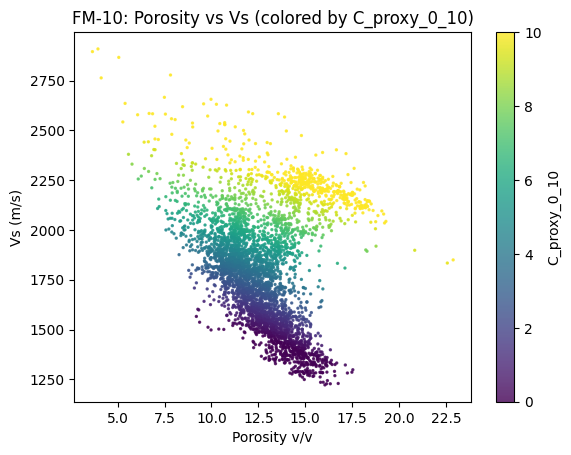

In [ ]:
fm10 = df_logs.loc[(df_logs.index >= z0) & (df_logs.index < z1)].copy()
fm10 = fm10[np.isfinite(fm10["Mu_GPa"]) & np.isfinite(fm10["phi"])]

plt.figure()
sc = plt.scatter(fm10["phi"]*100, fm10["Vs"], c=fm10["C_proxy_0_10"], s=2, cmap="viridis", alpha=0.8)
plt.xlabel("Porosity v/v")
plt.ylabel("Vs (m/s)")
plt.title("FM-10: Porosity vs Vs (colored by Cement volume)")
cbar = plt.colorbar(sc); cbar.set_label("Cement volume")
plt.show()